# 1-2. Dataset

In [2]:
import torch
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

cuda available: True
device count: 2
device name: Tesla T4
Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 32.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


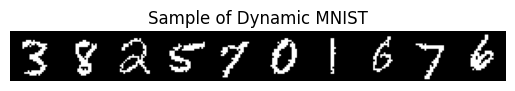

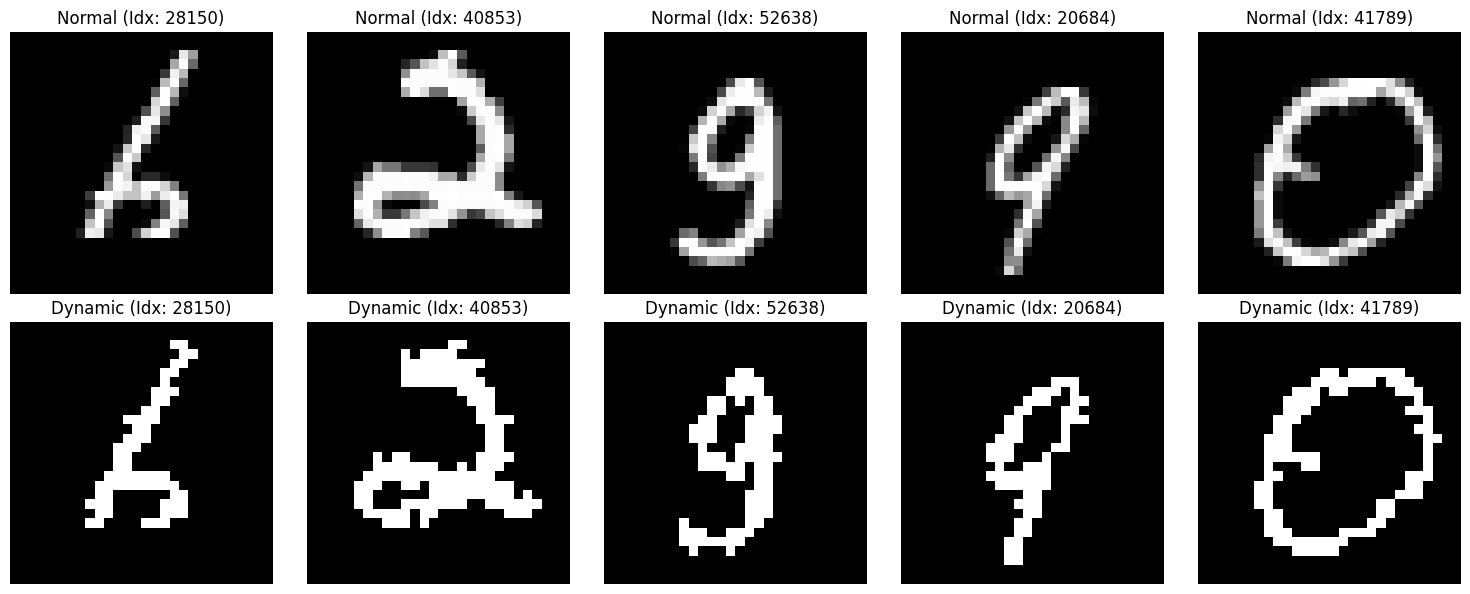

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


transform_dynamic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.bernoulli(x)) 
])

transform_normal = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform_dynamic)
loader = torch.utils.data.DataLoader(mnist_train, batch_size=10, shuffle=True)

images, labels = next(iter(loader))
grid_img = transforms.ToPILImage()(torch.cat([img for img in images], dim=2))
plt.axis('off')
plt.imshow(grid_img, cmap='gray')
plt.title("Sample of Dynamic MNIST")
plt.show()

mnist_normal = datasets.MNIST(root='./data', train=True, download=True, transform=transform_normal)
mnist_dynamic = datasets.MNIST(root='./data', train=True, download=True, transform=transform_dynamic)


num_samples = 5
indices = np.random.choice(len(mnist_normal), num_samples, replace=False)

fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

for i, idx in enumerate(indices):
    img_n, _ = mnist_normal[idx]
    axes[0, i].imshow(img_n.squeeze(), cmap='gray')
    axes[0, i].set_title(f"Normal (Idx: {idx})")
    axes[0, i].axis('off')
    
    img_d, _ = mnist_dynamic[idx]
    axes[1, i].imshow(img_d.squeeze(), cmap='gray')
    axes[1, i].set_title(f"Dynamic (Idx: {idx})")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 1-3. Implementing in low latent dimensions

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DynamicBinarize(object):
    def __call__(self, x):
        return torch.bernoulli(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    DynamicBinarize(),
])

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

Using device: cuda


In [ ]:
latent_dim = 2
input_dim = 28 * 28
hidden_dim = 300

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        
        self.enc1 = nn.Linear(input_dim, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)
        self.enc_mu = nn.Linear(hidden_dim, latent_dim)
        self.enc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.dec1 = nn.Linear(latent_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, hidden_dim)
        self.dec_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.enc1(x))
        h = torch.relu(self.enc2(h))
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.dec1(z))
        h = torch.relu(self.dec2(h))
        logits = self.dec_out(h)  
        return logits

    def forward(self, x):
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar, z

def vae_loss_std(logits, x, mu, logvar):
    x = x.view(x.size(0), -1)
    recon_loss = nn.functional.binary_cross_entropy_with_logits(
        logits, x, reduction='sum'
    ) / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    loss = recon_loss + kl
    return loss, recon_loss, kl


In [ ]:
LOG_2PI = math.log(2 * math.pi)

def log_normal_pdf(z, mu, logvar):
    return -0.5 * (logvar + (z - mu) ** 2 / logvar.exp() + LOG_2PI)

class VampPriorVAE(VAE):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2, K=500):
        super().__init__(input_dim, hidden_dim, latent_dim)
        self.K = K
        self.pseudo_inputs = nn.Parameter(torch.zeros(K, 1, 28, 28))
    
    def initialize_from_data(self, train_loader):
        x, _ = next(iter(train_loader))
        all_x = []
        for images, _ in train_loader:
            all_x.append(images.view(images.size(0), -1))
            if sum(b.size(0) for b in all_x) >= self.K:
                break
        
        x_init = torch.cat(all_x, dim=0)[:self.K]
        eps = 1e-4
        x_init = torch.clamp(x_init, eps, 1.0 - eps)
        x_logit = torch.log(x_init / (1.0 - x_init))
        
        self.pseudo_inputs.data.copy_(x_logit.view(self.K, 1, 28, 28))
        print(f"Successfully initialized {self.K} pseudo-inputs from training data.")

    def get_prior_params(self):
        u = torch.sigmoid(self.pseudo_inputs).view(self.K, -1)
        h = torch.relu(self.enc1(u))
        h = torch.relu(self.enc2(h))
        mu_p = self.enc_mu(h)
        logvar_p = self.enc_logvar(h)
        return mu_p, logvar_p


def vae_loss_vamp(model, logits, x, mu_q, logvar_q):
    x = x.view(x.size(0), -1)
    recon_loss = nn.functional.binary_cross_entropy_with_logits(
        logits, x, reduction='sum'
    ) / x.size(0)

    z = model.reparameterize(mu_q, logvar_q)
    log_qzx = torch.sum(log_normal_pdf(z, mu_q, logvar_q), dim=1)
    
    mu_p, logvar_p = model.get_prior_params()
    
    z_exp = z.unsqueeze(1)                     
    mu_p = mu_p.unsqueeze(0)                    
    logvar_p = logvar_p.unsqueeze(0)           

    log_pzk = torch.sum(log_normal_pdf(z_exp, mu_p, logvar_p), dim=2) 

    log_pz = torch.logsumexp(log_pzk - torch.log(torch.tensor(model.K, dtype=z.dtype, device=z.device)), dim=1) 

    
    kl = torch.mean(log_qzx - log_pz)
    loss = recon_loss + kl
    return loss, recon_loss, kl


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 100
epochs = 40

def train_model(model, train_loader, is_vamp=False, lr=1e-3, epochs=20):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'total': [], 'recon': [], 'kl': []}
    
    print(f"Starting Training ({'VampPrior' if is_vamp else 'Standard'})...")
    
    for epoch in range(epochs):
        model.train()
        running_loss, running_recon, running_kl = 0.0, 0.0, 0.0
        
        for x, _ in train_loader:
            x = x.to(device).view(x.size(0), -1)
            optimizer.zero_grad()
            
            logits, mu_q, logvar_q, _ = model(x)
            
            recon_loss = F.binary_cross_entropy_with_logits(logits, x, reduction='sum') / x.size(0)
            
            z = model.reparameterize(mu_q, logvar_q)
            log_qzx = torch.sum(log_normal_pdf(z, mu_q, logvar_q), dim=1)
            
            if not is_vamp:
                log_pz = torch.sum(log_normal_pdf(z, torch.zeros_like(z), torch.zeros_like(z)), dim=1)
            else:
                mu_p, logvar_p = model.get_prior_params()
                z_exp = z.unsqueeze(1)
                mu_p = mu_p.unsqueeze(0)
                logvar_p = logvar_p.unsqueeze(0)
                
                log_pzk = torch.sum(log_normal_pdf(z_exp, mu_p, logvar_p), dim=2)
                log_pz = torch.logsumexp(log_pzk - math.log(model.K), dim=1)
            
            kl = torch.mean(log_qzx - log_pz)
            
            loss = recon_loss + kl
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl.item()
            
        avg_loss = running_loss / len(train_loader)
        avg_recon = running_recon / len(train_loader)
        avg_kl = running_kl / len(train_loader)
        
        history['total'].append(avg_loss)
        history['recon'].append(avg_recon)
        history['kl'].append(avg_kl)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.2f}, Recon: {avg_recon:.2f}, KL: {avg_kl:.2f}")
        
    return history


std_vae = VAE(latent_dim=2).to(device)
vamp_vae = VampPriorVAE(latent_dim=2, K=500).to(device)

vamp_vae.initialize_from_data(train_ds)

history_std = train_model(std_vae, train_loader, is_vamp=False, epochs=epochs)
history_vamp = train_model(vamp_vae, train_loader, is_vamp=True, epochs=epochs)


Successfully initialized 500 pseudo-inputs from training data.
Starting Training (Standard)...
Epoch [1/40] - Loss: 183.42, Recon: 179.53, KL: 3.89
Epoch [2/40] - Loss: 160.54, Recon: 155.30, KL: 5.24
Epoch [3/40] - Loss: 154.55, Recon: 148.90, KL: 5.65
Epoch [4/40] - Loss: 151.21, Recon: 145.34, KL: 5.87
Epoch [5/40] - Loss: 148.95, Recon: 142.91, KL: 6.04
Epoch [6/40] - Loss: 147.29, Recon: 141.12, KL: 6.17
Epoch [7/40] - Loss: 146.11, Recon: 139.89, KL: 6.22
Epoch [8/40] - Loss: 145.19, Recon: 138.91, KL: 6.27
Epoch [9/40] - Loss: 144.23, Recon: 137.89, KL: 6.34
Epoch [10/40] - Loss: 143.60, Recon: 137.20, KL: 6.39
Epoch [11/40] - Loss: 143.07, Recon: 136.67, KL: 6.40
Epoch [12/40] - Loss: 142.55, Recon: 136.09, KL: 6.46
Epoch [13/40] - Loss: 142.21, Recon: 135.72, KL: 6.49
Epoch [14/40] - Loss: 141.86, Recon: 135.36, KL: 6.50
Epoch [15/40] - Loss: 141.48, Recon: 134.94, KL: 6.54
Epoch [16/40] - Loss: 141.17, Recon: 134.62, KL: 6.55
Epoch [17/40] - Loss: 141.08, Recon: 134.49, KL: 6

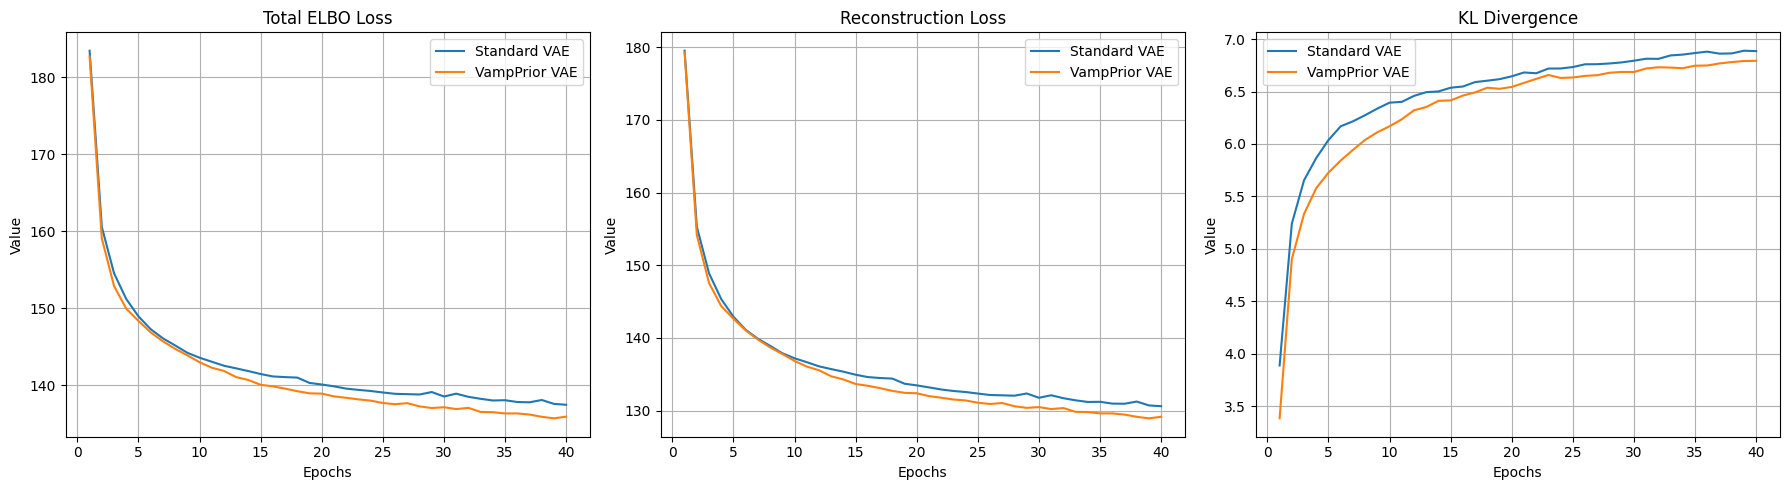

In [8]:
ticks = range(0, len(history_std["total"]) + 1, 5)
epochs_range = range(1, len(history_std["total"]) + 1)

def plot_comparison(h_std, h_vamp):
    metrics = ['total', 'recon', 'kl']
    titles = ['Total ELBO Loss', 'Reconstruction Loss', 'KL Divergence']
    plt.figure(figsize=(18, 5))
    
    for i, m in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        plt.plot(epochs_range, h_std[m], label='Standard VAE')
        plt.plot(epochs_range, h_vamp[m], label='VampPrior VAE')
        plt.title(titles[i])
        plt.xticks(ticks)
        plt.xlabel('Epochs')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_comparison(history_std, history_vamp)

# 1-4. Examination of Latent Dimension Distribution

Generating Latent Space for Standard VAE...


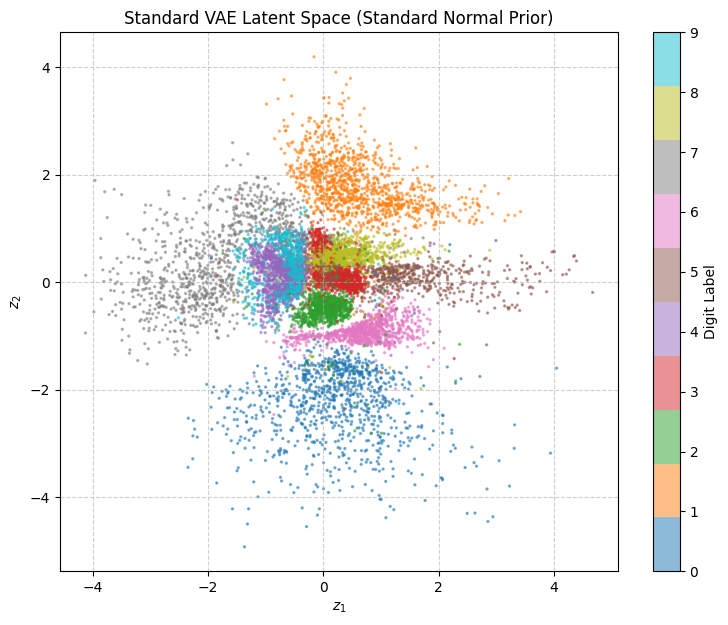

Generating Latent Space for VampPrior VAE...


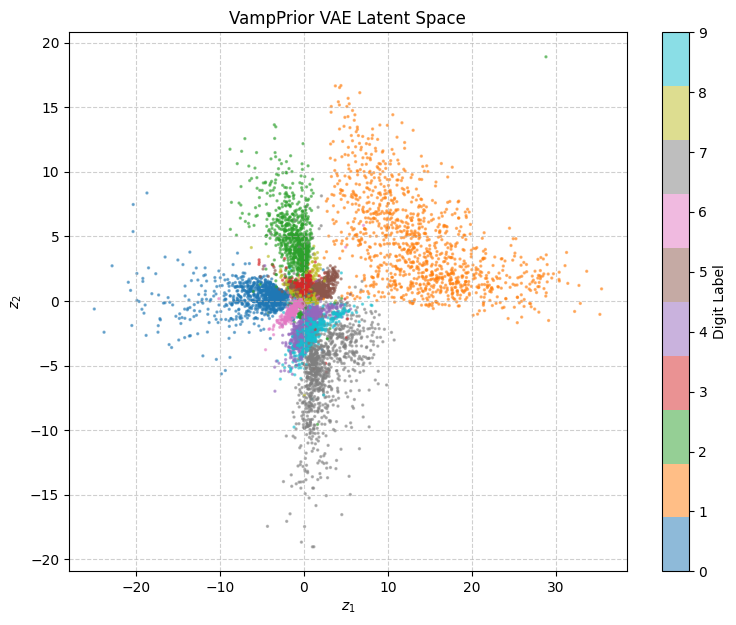

In [9]:
def visualize_latent_distribution(model, data_loader, title="Latent Space"):
    model.eval()
    all_mu = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device).view(x.size(0), -1)
            mu, _ = model.encode(x) 
            all_mu.append(mu.cpu().numpy())
            all_labels.append(y.numpy())
            
    all_mu = np.concatenate(all_mu, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=2)
    plt.colorbar(scatter, ticks=range(10), label='Digit Label')
    plt.title(title)
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

print("Generating Latent Space for Standard VAE...")
visualize_latent_distribution(std_vae, test_loader, "Standard VAE Latent Space (Standard Normal Prior)")

print("Generating Latent Space for VampPrior VAE...")
visualize_latent_distribution(vamp_vae, test_loader, "VampPrior VAE Latent Space")

Plotting Densities for Standard VAE...


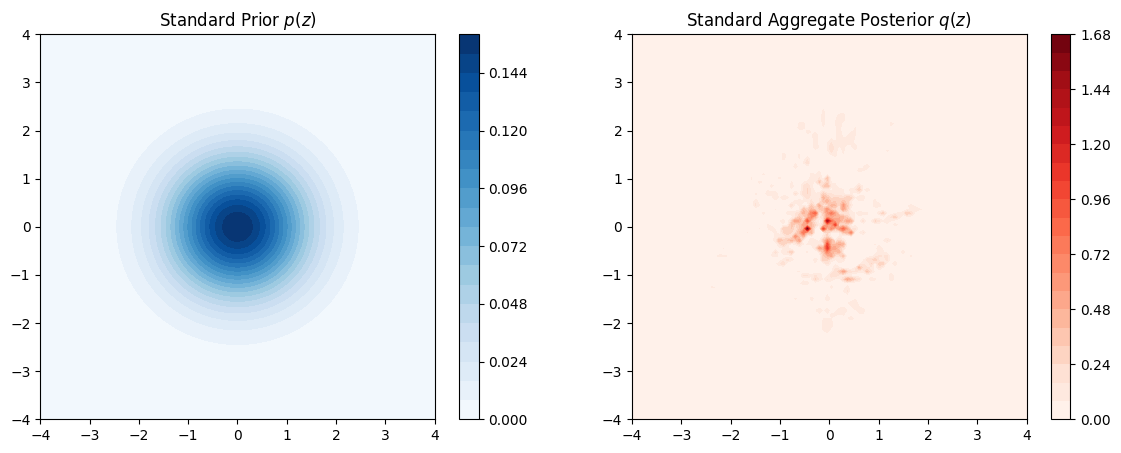

Plotting Densities for VampPrior VAE...


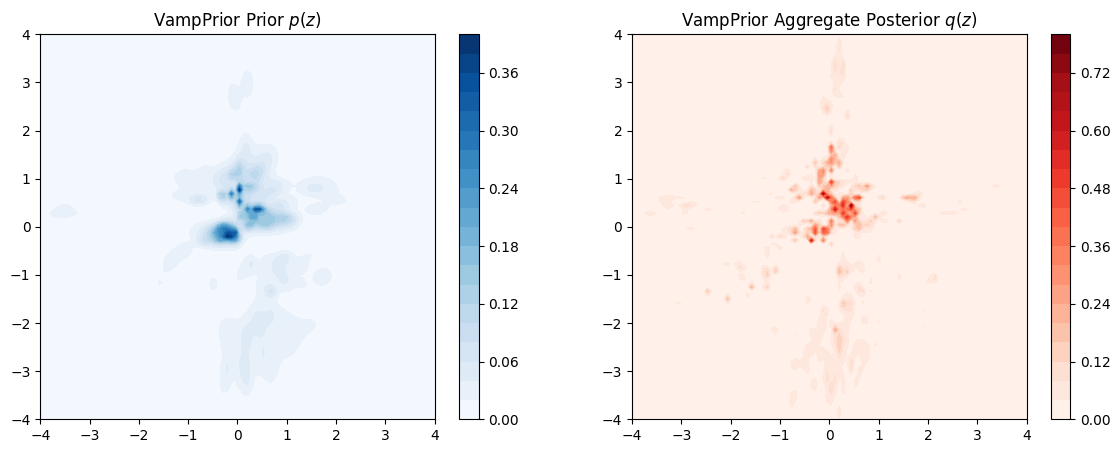

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prior_posterior_density(model, data_loader, is_vamp=False, title_prefix=""):
    model.eval()
    
    grid_res = 100
    z1 = np.linspace(-4, 4, grid_res)
    z2 = np.linspace(-4, 4, grid_res)
    Z1, Z2 = np.meshgrid(z1, z2)
    grid_coords = torch.FloatTensor(np.dstack([Z1, Z2])).to(device).view(-1, 2)

    with torch.no_grad():
        if not is_vamp:
            log_pz = torch.sum(log_normal_pdf(grid_coords, torch.zeros_like(grid_coords), torch.zeros_like(grid_coords)), dim=1)
        else:
            mu_p, logvar_p = model.get_prior_params()
            z_grid_exp = grid_coords.unsqueeze(1)
            mu_p_exp = mu_p.unsqueeze(0)
            logvar_p_exp = logvar_p.unsqueeze(0)
            
            log_pzk = torch.sum(log_normal_pdf(z_grid_exp, mu_p_exp, logvar_p_exp), dim=2)
            log_pz = torch.logsumexp(log_pzk - math.log(model.K), dim=1)
        
        prior_density = torch.exp(log_pz).view(grid_res, grid_res).cpu().numpy()

    all_mu, all_logvar = [], []
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device).view(x.size(0), -1)
            mu, logvar = model.encode(x)
            all_mu.append(mu)
            all_logvar.append(logvar)

    mu_q = torch.cat(all_mu, dim=0)[:1000]
    logvar_q = torch.cat(all_logvar, dim=0)[:1000]
    
    with torch.no_grad():
        z_grid_exp = grid_coords.unsqueeze(1)
        mu_q_exp = mu_q.unsqueeze(0)
        logvar_q_exp = logvar_q.unsqueeze(0)
        
        log_qzk = torch.sum(log_normal_pdf(z_grid_exp, mu_q_exp, logvar_q_exp), dim=2)
        log_qz = torch.logsumexp(log_qzk - math.log(mu_q.size(0)), dim=1)
        posterior_density = torch.exp(log_qz).view(grid_res, grid_res).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im1 = axes[0].contourf(Z1, Z2, prior_density, levels=20, cmap='Blues')
    axes[0].set_title(f"{title_prefix} Prior $p(z)$")
    fig.colorbar(im1, ax=axes[0])
    
    im2 = axes[1].contourf(Z1, Z2, posterior_density, levels=20, cmap='Reds')
    axes[1].set_title(f"{title_prefix} Aggregate Posterior $q(z)$")
    fig.colorbar(im2, ax=axes[1])
    
    plt.show()

print("Plotting Densities for Standard VAE...")
plot_prior_posterior_density(std_vae, test_loader, is_vamp=False, title_prefix="Standard")

print("Plotting Densities for VampPrior VAE...")
plot_prior_posterior_density(vamp_vae, test_loader, is_vamp=True, title_prefix="VampPrior")

# 1-5. Implementing in high latent dimensions

In [11]:
std_vae_40 = VAE(latent_dim=40).to(device)
vamp_vae_40 = VampPriorVAE(latent_dim=40, K=500).to(device)

vamp_vae_40.initialize_from_data(train_ds)

history_std_40 = train_model(std_vae_40, train_loader, is_vamp=False, epochs=epochs)
history_vamp_40 = train_model(vamp_vae_40, train_loader, is_vamp=True, epochs=epochs)

Successfully initialized 500 pseudo-inputs from training data.
Starting Training (Standard)...
Epoch [1/40] - Loss: 183.60, Recon: 177.39, KL: 6.21
Epoch [2/40] - Loss: 135.53, Recon: 122.29, KL: 13.24
Epoch [3/40] - Loss: 122.27, Recon: 107.33, KL: 14.94
Epoch [4/40] - Loss: 116.19, Recon: 100.06, KL: 16.13
Epoch [5/40] - Loss: 112.17, Recon: 95.12, KL: 17.05
Epoch [6/40] - Loss: 109.35, Recon: 91.79, KL: 17.56
Epoch [7/40] - Loss: 107.59, Recon: 89.72, KL: 17.86
Epoch [8/40] - Loss: 106.24, Recon: 87.99, KL: 18.25
Epoch [9/40] - Loss: 105.09, Recon: 86.53, KL: 18.56
Epoch [10/40] - Loss: 104.15, Recon: 85.35, KL: 18.80
Epoch [11/40] - Loss: 103.45, Recon: 84.43, KL: 19.02
Epoch [12/40] - Loss: 102.69, Recon: 83.44, KL: 19.24
Epoch [13/40] - Loss: 101.93, Recon: 82.51, KL: 19.42
Epoch [14/40] - Loss: 101.36, Recon: 81.72, KL: 19.63
Epoch [15/40] - Loss: 100.90, Recon: 81.15, KL: 19.75
Epoch [16/40] - Loss: 100.39, Recon: 80.50, KL: 19.88
Epoch [17/40] - Loss: 100.03, Recon: 79.99, KL:

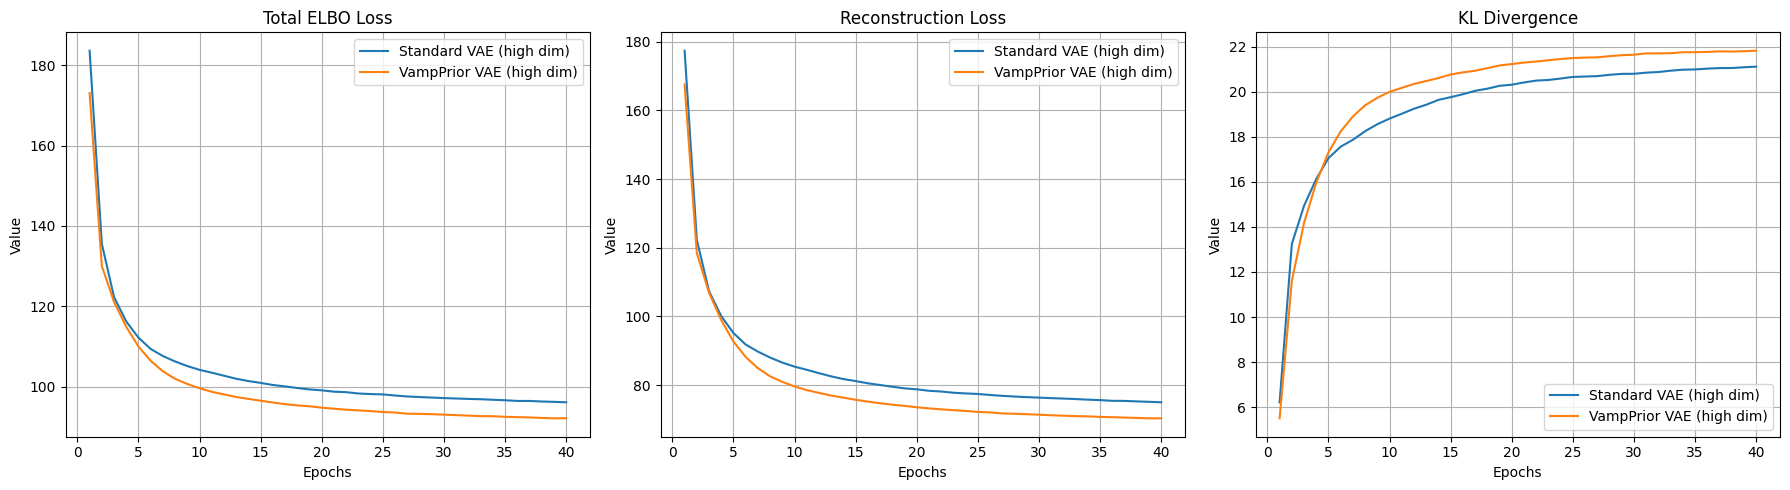

In [12]:
ticks = range(0, len(history_std_40["total"]) + 1, 5)
epochs_range = range(1, len(history_std_40["total"]) + 1)

def plot_comparison(h_std, h_vamp):
    metrics = ['total', 'recon', 'kl']
    titles = ['Total ELBO Loss', 'Reconstruction Loss', 'KL Divergence']
    plt.figure(figsize=(18, 5))
    
    for i, m in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        plt.plot(epochs_range, h_std[m], label='Standard VAE (high dim)')
        plt.plot(epochs_range, h_vamp[m], label='VampPrior VAE (high dim)')
        plt.title(titles[i])
        plt.xticks(ticks)
        plt.xlabel('Epochs')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_comparison(history_std_40, history_vamp_40)

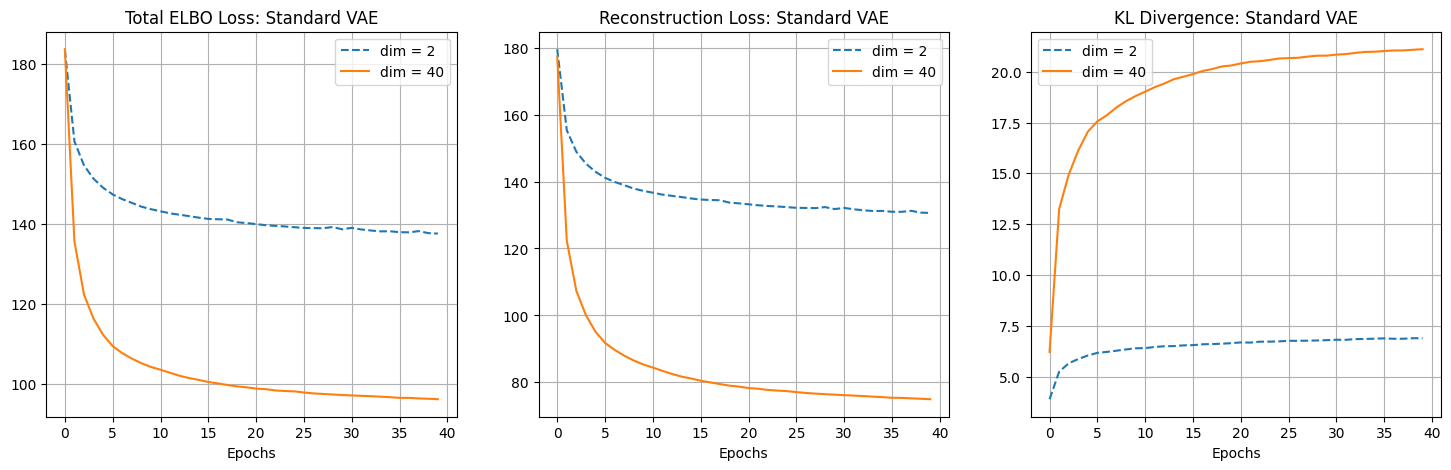

<Figure size 1800x500 with 0 Axes>

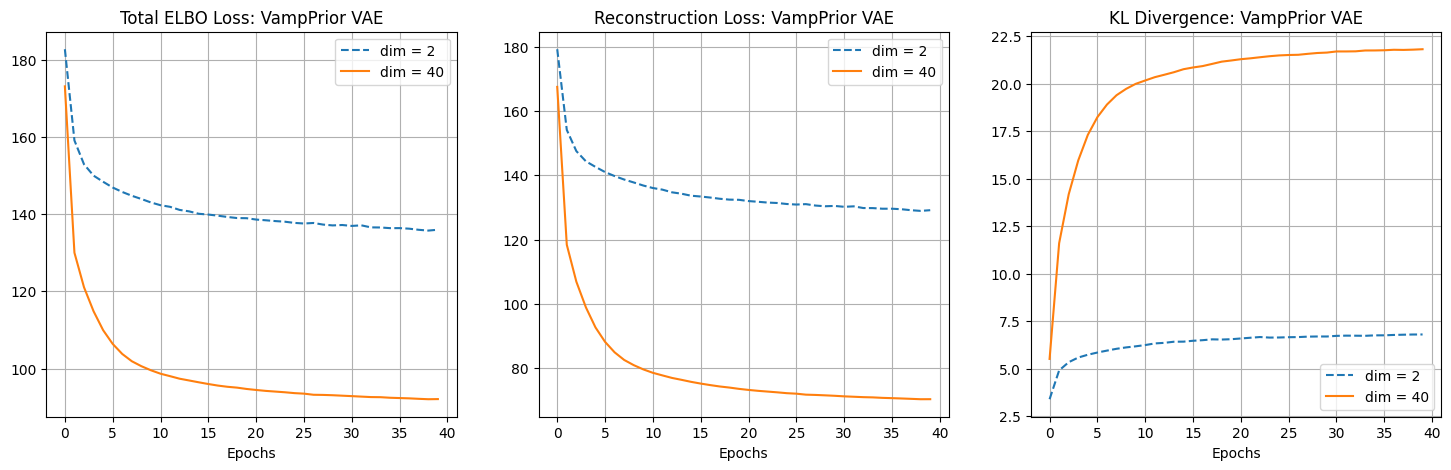

<Figure size 1800x500 with 0 Axes>

In [13]:
def plot_dim_comparison(low_dim_hist, high_dim_hist, model_name="VAE"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['total', 'recon', 'kl']
    titles = [f'Total ELBO Loss: {model_name}', f'Reconstruction Loss: {model_name}', f'KL Divergence: {model_name}']
    plt.figure(figsize=(18, 5))
    
    for i, metric in enumerate(metrics):
        axes[i].plot(low_dim_hist[metric], label='dim = 2', linestyle='--')
        axes[i].plot(high_dim_hist[metric], label='dim = 40')
        axes[i].set_title(titles[i])
        axes[i].set_xlabel('Epochs')
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_dim_comparison(history_std, history_std_40, model_name="Standard VAE")
plot_dim_comparison(history_vamp, history_vamp_40, model_name="VampPrior VAE")

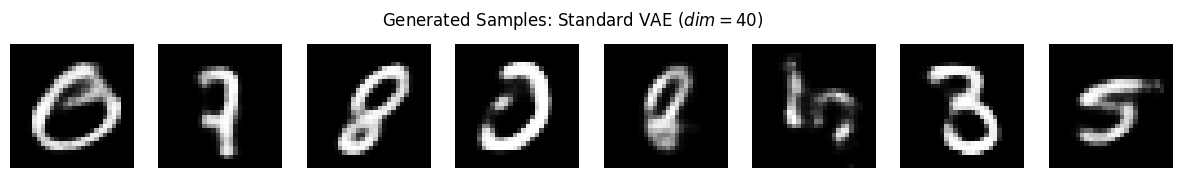

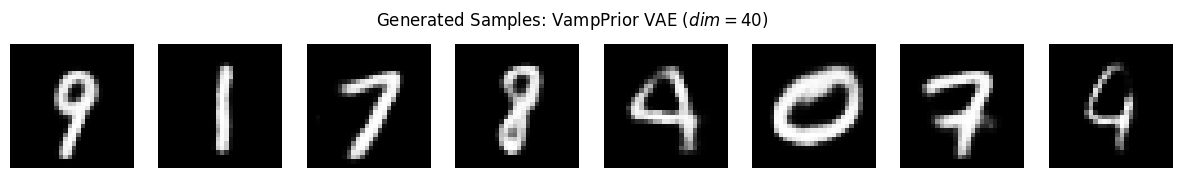

In [ ]:
import torch
import matplotlib.pyplot as plt

def generate_and_compare_separate(std_model, vamp_model, latent_dim=40, num_samples=8):
    std_model.eval()
    vamp_model.eval()
    
    with torch.no_grad():
        z_std = torch.randn(num_samples, latent_dim).to(device)
        samples_std = torch.sigmoid(std_model.decode(z_std)).cpu().view(-1, 28, 28)
        mu_p, logvar_p = vamp_model.get_prior_params()
        idx = torch.randint(0, vamp_model.K, (num_samples,))
        z_vamp = vamp_model.reparameterize(mu_p[idx], logvar_p[idx])
        samples_vamp = torch.sigmoid(vamp_model.decode(z_vamp)).cpu().view(-1, 28, 28)

    plt.figure(figsize=(15, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(samples_std[i], cmap='gray')
        plt.axis('off')
    plt.suptitle("Generated Samples: Standard VAE ($dim=40$)")
    plt.show()

    plt.figure(figsize=(15, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(samples_vamp[i], cmap='gray')
        plt.axis('off')
    plt.suptitle("Generated Samples: VampPrior VAE ($dim=40$)")
    plt.show()

generate_and_compare_separate(std_vae_40, vamp_vae_40, latent_dim=40)

# 1-6. Investigation of Posterior Collapse

Standard VAE Active Units: 17 / 40
VampPrior VAE Active Units: 20 / 40


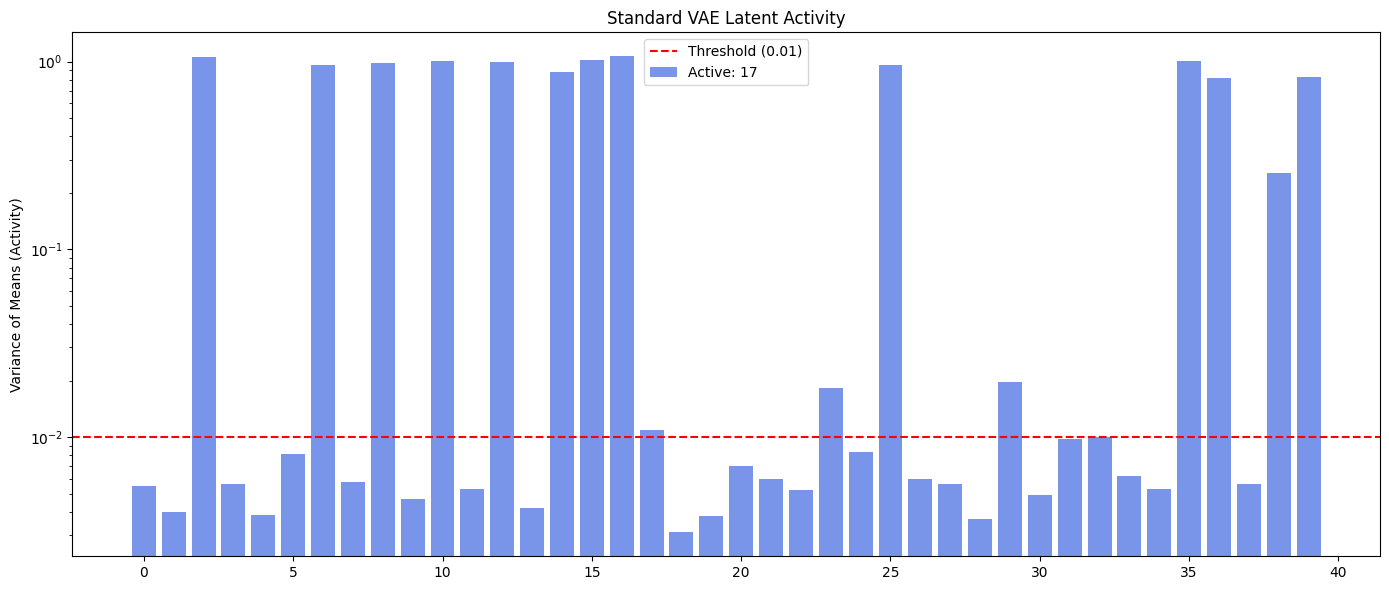

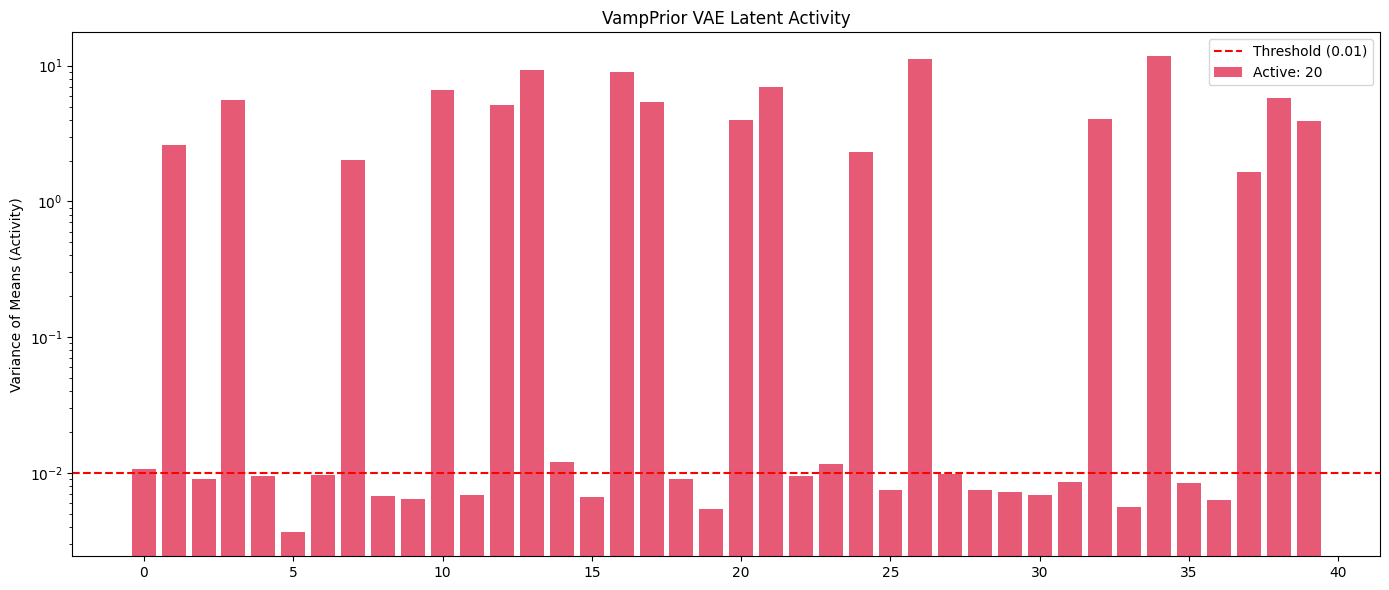

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_posterior_collapse(model, data_loader, threshold=0.01):
    model.eval()
    all_mu = []
    
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device).view(x.size(0), -1)
            mu, _ = model.encode(x) 
            all_mu.append(mu.cpu())

    all_mu = torch.cat(all_mu, dim=0)
    
    var_per_dim = all_mu.var(dim=0).numpy()
    
    active_units = np.sum(var_per_dim > threshold)
    
    return var_per_dim, active_units

var_std, active_std = analyze_posterior_collapse(std_vae_40, test_loader)
var_vamp, active_vamp = analyze_posterior_collapse(vamp_vae_40, test_loader)

print(f"Standard VAE Active Units: {active_std} / 40")
print(f"VampPrior VAE Active Units: {active_vamp} / 40")


plt.figure(figsize=(14, 6))
dims = np.arange(40)

plt.bar(dims, var_std, color='royalblue', alpha=0.7, label=f'Active: {active_std}')
plt.axhline(y=0.01, color='r', linestyle='--', label='Threshold (0.01)')
plt.ylabel('Variance of Means (Activity)')
plt.title("Standard VAE Latent Activity")
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(dims, var_vamp, color='crimson', alpha=0.7, label=f'Active: {active_vamp}')
plt.axhline(y=0.01, color='r', linestyle='--', label='Threshold (0.01)')
plt.ylabel('Variance of Means (Activity)')
plt.title("VampPrior VAE Latent Activity")
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

# 1-7. Hidden Space

Standard VAE Traversal:


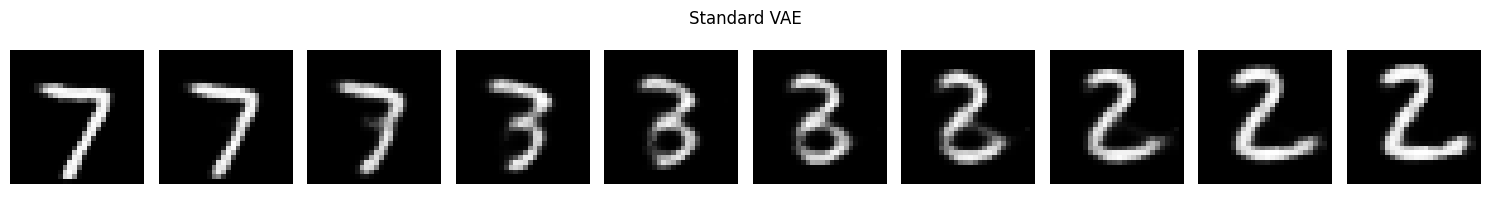

VampPrior VAE Traversal:


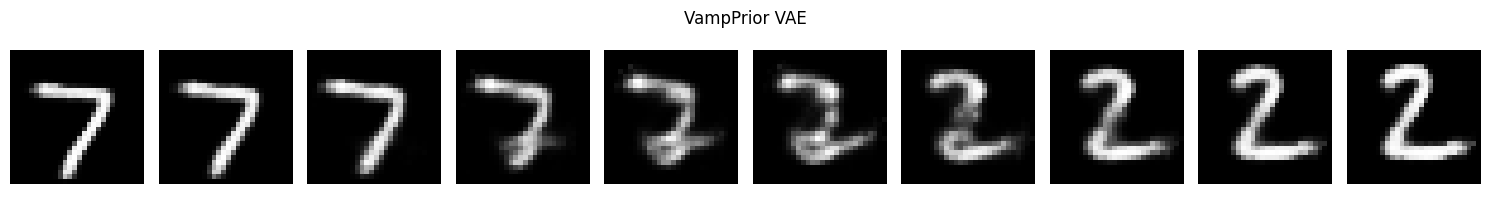

In [16]:
def plot_latent_traversal(model, test_loader, title, num_steps=10):
    model.eval()
    with torch.no_grad():

        data, _ = next(iter(test_loader))
        x_A = data[0:1].to(device).view(1, -1)
        x_B = data[1:2].to(device).view(1, -1)

        mu_A, _ = model.encode(x_A)
        mu_B, _ = model.encode(x_B)

        alphas = np.linspace(0, 1, num_steps)
        traversal_images = []

        for alpha in alphas:
            z_interp = (1 - alpha) * mu_A + alpha * mu_B
            logits = model.decode(z_interp)
            probs = torch.sigmoid(logits)
            traversal_images.append(probs.view(28, 28).cpu())

        plt.figure(figsize=(15, 2))
        plt.title(title)
        plt.axis('off')
        for i, img in enumerate(traversal_images):
            plt.subplot(1, num_steps, i + 1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

print("Standard VAE Traversal:")
plot_latent_traversal(std_vae_40, test_loader, "Standard VAE")
print("VampPrior VAE Traversal:")
plot_latent_traversal(vamp_vae_40, test_loader, "VampPrior VAE")

# 1-8. Visualizing Pseudo-inputs

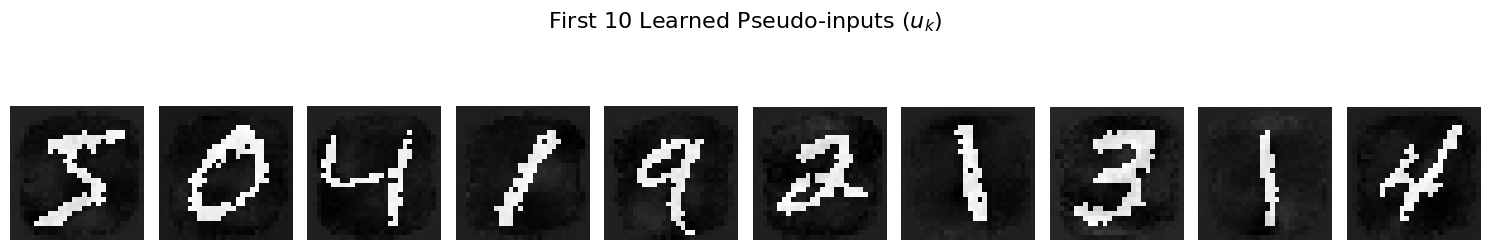

In [17]:
def plot_pseudo_inputs(model, num_to_show=10):
    model.eval()
    with torch.no_grad():
        pseudos = model.pseudo_inputs.cpu()
    
    plt.figure(figsize=(15, 3))
    for i in range(num_to_show):
        plt.subplot(1, num_to_show, i + 1)
        img = pseudos[i].view(28, 28)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.suptitle(f"First {num_to_show} Learned Pseudo-inputs ($u_k$)", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_pseudo_inputs(vamp_vae_40)


Visualizing Pseudo-Inputs...


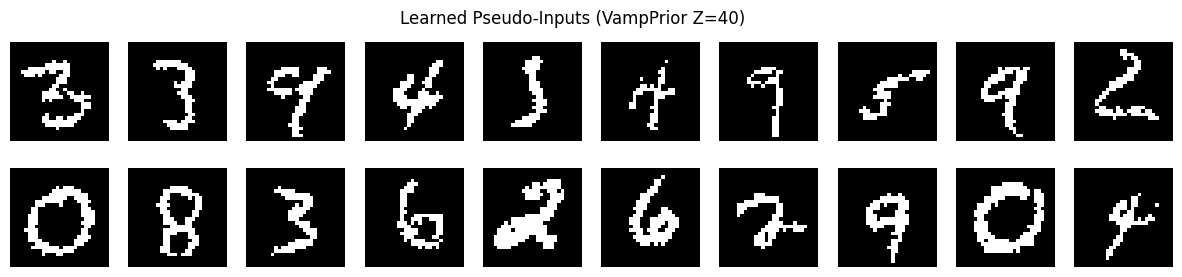

In [18]:
def visualize_pseudo_inputs(model, num_display=20):
    model.eval()
    

    pseudos = model.pseudo_inputs.data.cpu()
    
    
    pseudos_img = torch.sigmoid(pseudos) 
    
    indices = torch.randperm(pseudos.size(0))[:num_display]
    selected_pseudos = pseudos_img[indices]
    
    plt.figure(figsize=(15, 3))
    for i in range(num_display):
        ax = plt.subplot(2, num_display//2, i + 1)
        plt.imshow(selected_pseudos[i].view(28, 28), cmap='gray')
        plt.axis('off')
        
    plt.suptitle(f'Learned Pseudo-Inputs (VampPrior Z={model.enc_mu.out_features})')
    plt.show()

print("\nVisualizing Pseudo-Inputs...")
visualize_pseudo_inputs(vamp_vae_40, num_display=20)


# 1-9. Calculating Log-Likelihood

In [ ]:
def calculate_log_likelihood(model, data_loader, num_samples=500, is_vamp=False):
    model.eval()
    total_ll = 0
    
    latent_dim = model.enc_mu.out_features 
    
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device).view(x.size(0), -1)
            batch_size = x.size(0)
            
            mu_q, logvar_q = model.encode(x)
            
            eps = torch.randn(num_samples, batch_size, latent_dim).to(device)
            z = mu_q.unsqueeze(0) + eps * torch.exp(0.5 * logvar_q.unsqueeze(0))
            log_q_zx = torch.sum(log_normal_pdf(z, mu_q.unsqueeze(0), logvar_q.unsqueeze(0)), dim=2)
            z_flat = z.view(-1, latent_dim)
            logits_flat = model.decode(z_flat)
            x_exp = x.repeat(num_samples, 1)
            log_p_xz = -F.binary_cross_entropy_with_logits(logits_flat, x_exp, reduction='none').sum(1)
            log_p_xz = log_p_xz.view(num_samples, batch_size)
            
            if not is_vamp:
                log_p_z = torch.sum(log_normal_pdf(z, torch.zeros_like(z), torch.zeros_like(z)), dim=2)
            else:
                mu_p, logvar_p = model.get_prior_params()
                z_exp = z.unsqueeze(2)
                log_p_zk = torch.sum(log_normal_pdf(z_exp, mu_p.view(1,1,model.K,-1), 
                                                    logvar_p.view(1,1,model.K,-1)), dim=3)
                log_p_z = torch.logsumexp(log_p_zk - math.log(model.K), dim=2)
            
            log_weight = log_p_xz + log_p_z - log_q_zx
            batch_ll = torch.logsumexp(log_weight, dim=0) - math.log(num_samples)
            total_ll += batch_ll.sum().item()
            
    return total_ll / len(data_loader.dataset)

In [20]:
std_vae.to(device)
vamp_vae.to(device)
std_vae_40.to(device)
vamp_vae_40.to(device)

print(f"Calculating Marginal Log-Likelihood for VAE Models...")
ll_std = calculate_log_likelihood(std_vae, test_loader, num_samples=500, is_vamp=False)
ll_vamp = calculate_log_likelihood(vamp_vae, test_loader, num_samples=500, is_vamp=True)
ll_std_40 = calculate_log_likelihood(std_vae_40, test_loader, num_samples=500, is_vamp=False)
ll_vamp_40 = calculate_log_likelihood(vamp_vae_40, test_loader, num_samples=500, is_vamp=True)

Calculating Marginal Log-Likelihood for VAE Models...


In [21]:
print("\n" + "="*50)
print(f"RESULTS (Importance Sampling S=500)")
print(f"Standard VAE (Latent Dimension = 2):    {ll_std:.2f}")
print(f"VampPrior VAE (Latent Dimension = 2):   {ll_vamp:.2f}")
print(f"Standard VAE (Latent Dimension = 40):   {ll_std_40:.2f}")
print(f"VampPrior VAE (Latent Dimension = 40):  {ll_vamp_40:.2f}")
print("="*50)


RESULTS (Importance Sampling S=500)
Standard VAE (Latent Dimension = 2):    -135.04
VampPrior VAE (Latent Dimension = 2):   -133.17
Standard VAE (Latent Dimension = 40):   -91.58
VampPrior VAE (Latent Dimension = 40):  -87.71
